## DRAFT 

nilearn pipeline for moving from HCP cii file to correlation matrix 

will clean this up 

also need to concatenate LR / RL data 

In [1]:
# split cii into gii 

from cloudpathlib import S3Path, S3Client
import nibabel as nib
import neuropythy as ny

# The base HCP path:
base_path = S3Path(
    's3://hcp-openaccess/HCP_1200/',
    client=S3Client(profile_name='hcp'))

# Find an example cifti file:
sid = 111312
rs_dirpath = base_path / str(sid) / 'MNINonLinear' / 'Results' / 'tfMRI_GAMBLING_RL' 
cifti_filepath = rs_dirpath / 'tfMRI_GAMBLING_RL_Atlas_MSMAll.dtseries.nii'

# Load the cifti object:
cii = nib.load(cifti_filepath.fspath)

(lhdat, rhdat, subdat) = ny.hcp.cifti_split(cii)
print('LH:', lhdat.shape)
print('RH:', rhdat.shape)

our_data = (lhdat, rhdat)

/srv/conda/envs/notebook/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


LH: (253, 32492)
RH: (253, 32492)


In [21]:
# make a mesh object

import hcp_utils as hcp
from nilearn.surface import InMemoryMesh, PolyMesh

# define the mesh for the left and right hemispheres
left_coords, left_faces = hcp.mesh["pial_left"]
right_coords, right_faces = hcp.mesh["pial_right"]

#PolyMesh is like a dictionary - keys are left and right 
mesh = PolyMesh(
    left=InMemoryMesh(left_coords, left_faces),
    right=InMemoryMesh(right_coords, right_faces),
)

In [22]:
# parcellate mesh based on Glasser MMP specs

from nilearn.surface import SurfaceImage

# USING GLASSER MMP 
# we use the Multi Modal Parcellation (MMP) provided in hcp_utils
# https://rmldj.github.io/hcp-utils/parcellation_labels.html
parc = hcp.mmp
right_data = hcp.right_cortex_data(parc.map_all)
left_data = hcp.left_cortex_data(parc.map_all)

data = {
    "left": left_data,
    "right": right_data,
}

#labels for Glasser parcelation 
labels_image = SurfaceImage(mesh=mesh, data=data)

In [24]:
# look up table 

import pandas as pd

# we define a BIDS-formatted Look Up Table (LUT)
# this will follow the structure shown here :
# https://bids-specification.readthedocs.io/en/stable/derivatives/imaging.html#atlas-tabular-data 

lut = pd.DataFrame(parc.labels.values(), index=parc.labels.keys(), columns=["name"])
lut.iloc[0] = "Background"
lut['color'] = parc.rgba.values()
lut['index'] = lut.index
lut.head()

,name,color,index
0,Background,"[0.0, 0.0, 0.0, 0.0]",0
1,L_V1,"[0.262745, 0.0392157, 1.0, 1.0]",1
2,L_MST,"[0.192157, 0.356863, 0.498039, 1.0]",2
3,L_V6,"[0.192157, 0.333333, 0.658824, 1.0]",3
4,L_V2,"[0.0509804, 0.2, 0.929412, 1.0]",4


In [25]:
import numpy as np

np.shape(lut)

(380, 3)

In [26]:
lut[350:380]

,name,color,index
350,R_p10p,"[0.411765, 0.286275, 0.34902, 1.0]",350
351,R_p47r,"[0.635294, 0.443137, 0.494118, 1.0]",351
352,R_TGv,"[0.247059, 0.25098, 0.215686, 1.0]",352
353,R_MBelt,"[0.741176, 0.0392157, 0.0901961, 1.0]",353
354,R_LBelt,"[0.835294, 0.0901961, 0.117647, 1.0]",354
355,R_A4,"[0.607843, 0.137255, 0.0352941, 1.0]",355
356,R_STSva,"[0.168627, 0.141176, 0.109804, 1.0]",356
357,R_TE1m,"[0.360784, 0.207843, 0.239216, 1.0]",357
358,R_PI,"[0.498039, 0.207843, 0.219608, 1.0]",358
359,R_a32pr,"[0.619608, 0.301961, 0.415686, 1.0]",359


In [27]:
# make and fit the masker to the ROIs from Glasser 
# we have not supplied any data 

from nilearn.maskers import SurfaceLabelsMasker

# nilearn has many masker options 
# "deterministic parcellation in the surface" 

surface_lbls_masker = SurfaceLabelsMasker(labels_img=labels_image, lut=lut).fit()
# fitting on the labels image 
report = surface_lbls_masker.generate_report()
report

# to get connectivity 
"""
go to the tutorial: Connectivity with SurfaceLabelsMasker 
labels_masker.transform(data)
ConnectivityMeasure function from nilearn example 

we pass gifti files to create the surfaces images we apply the mask on 
does not work for cii --> split with Noah's code 
"""


"\ngo to the tutorial: Connectivity with SurfaceLabelsMasker \nlabels_masker.transform(data)\nConnectivityMeasure function from nilearn example \n\nwe pass gifti files to create the surfaces images we apply the mask on \ndoes not work for cii --> split with Noah's code \n"

In [ ]:
# put our data in SurfaceImage object 
# now that we have the labels from Glasser 

func_data = SurfaceImage(
    mesh=labels_image.mesh,
    data= {
        "left": lhdat.T,
        "right": rhdat.T
    }
)

In [28]:
# use fitted masker to transform data

roi_time_series = surface_lbls_masker.transform(func_data)
roi_time_series.shape


(253, 360)

In [29]:
# make connectivity matrix 

from nilearn.connectome import ConnectivityMeasure

correlation_measure = ConnectivityMeasure(kind='correlation')
correlation_matrix = correlation_measure.fit_transform([roi_time_series])[0]


/tmp/ipykernel_1946/3052818118.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  correlation_matrix = correlation_measure.fit_transform([roi_time_series])[0]


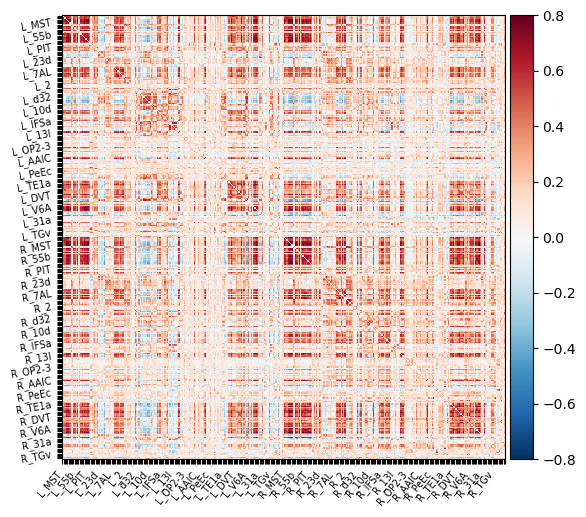

In [52]:
# plot correlation matrix 
# probably need to change the labels source 
from nilearn import plotting

labels = []
for i, label in enumerate(lut['name'].tolist()[1:361]):
    if i % 10 == 1:
        labels.append(label)
    else:
        labels.append("")

np.fill_diagonal(correlation_matrix, 0)
plotting.plot_matrix(correlation_matrix, labels=labels,
                     vmax=0.8, vmin=-0.8, colorbar=True)

In [27]:
np.shape(correlation_matrix)

(360, 360)

In [46]:
lut['name'].tolist()[:361]


['Background',
 'L_V1',
 'L_MST',
 'L_V6',
 'L_V2',
 'L_V3',
 'L_V4',
 'L_V8',
 'L_4',
 'L_3b',
 'L_FEF',
 'L_PEF',
 'L_55b',
 'L_V3A',
 'L_RSC',
 'L_POS2',
 'L_V7',
 'L_IPS1',
 'L_FFC',
 'L_V3B',
 'L_LO1',
 'L_LO2',
 'L_PIT',
 'L_MT',
 'L_A1',
 'L_PSL',
 'L_SFL',
 'L_PCV',
 'L_STV',
 'L_7Pm',
 'L_7m',
 'L_POS1',
 'L_23d',
 'L_v23ab',
 'L_d23ab',
 'L_31pv',
 'L_5m',
 'L_5mv',
 'L_23c',
 'L_5L',
 'L_24dd',
 'L_24dv',
 'L_7AL',
 'L_SCEF',
 'L_6ma',
 'L_7Am',
 'L_7PL',
 'L_7PC',
 'L_LIPv',
 'L_VIP',
 'L_MIP',
 'L_1',
 'L_2',
 'L_3a',
 'L_6d',
 'L_6mp',
 'L_6v',
 'L_p24pr',
 'L_33pr',
 'L_a24pr',
 'L_p32pr',
 'L_a24',
 'L_d32',
 'L_8BM',
 'L_p32',
 'L_10r',
 'L_47m',
 'L_8Av',
 'L_8Ad',
 'L_9m',
 'L_8BL',
 'L_9p',
 'L_10d',
 'L_8C',
 'L_44',
 'L_45',
 'L_47l',
 'L_a47r',
 'L_6r',
 'L_IFJa',
 'L_IFJp',
 'L_IFSp',
 'L_IFSa',
 'L_p9-46v',
 'L_46',
 'L_a9-46v',
 'L_9-46d',
 'L_9a',
 'L_10v',
 'L_a10p',
 'L_10pp',
 'L_11l',
 'L_13l',
 'L_OFC',
 'L_47s',
 'L_LIPd',
 'L_6a',
 'L_i6-8',
 'L_s6-8',